In [1]:
import importlib
import data_prep

importlib.reload(data_prep)

<module 'data_prep' from '/Users/ehabhasan/Documents/Projects/Time Series Forecasting/Large Scale Forecasting/EU Electricity Load Forecasting/data_prep.py'>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import data_prep  
from prophet import Prophet
import seaborn as sns


pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Avoid line wrapping
pd.set_option('display.max_colwidth', None) # Show full content of each cell

In [3]:
data=pd.read_csv('Data/data.csv')
data['Date']=pd.to_datetime(data['Date'],errors='coerce')
data['Date'] = data['Date'].dt.floor('h')
data.head()

,Date,CountryCode,Value,Temp_C,Humidity,WindSpeed,SolarRadiation,CloudCover
0,2023-01-01 00:00:00,AT,5280.8,4.2,77,13.0,0.0,82
1,2023-01-01 01:00:00,AT,5143.0,3.9,78,11.5,0.0,100
2,2023-01-01 02:00:00,AT,4958.7,3.7,76,11.6,0.0,100
3,2023-01-01 03:00:00,AT,4905.4,2.9,78,9.5,0.0,98
4,2023-01-01 04:00:00,AT,5025.8,1.8,83,6.9,0.0,100


# Metadata Analysis

## Notes:
- We have clean dataset no nulls or empty values, and data type as expected
- Countries: 24 unique CountryCode entries, CountryCode needs label encoding
- Date Range: From 2023-01-01 00:00:00 to 2025-03-31 23:00:00,  237 days per country
- Low cardinality of CountryCode is  good for one-hot encoding or embeddings
- Based on the most frequent value (mode) We notice that:
    - 742 Could be an off-hour low load, possibly from night hours in a small country
    - 7.2 most common temperature recorded
    - high humid conditions dominate most EU countries, slightly left skewed 
    - Most frequent value is 0 for solar Radiation confirms night hours (no sun)
    - Cloudy regions dominate, the data slightly skewed left where most values near 100
- The arithmetic average of a column can helps you understand the central tendency of a feature.But it can be sensitive to outliers, especially in skewed distributions:
    - The mean of Value is 11753.2 indicate average hourly electricty load (MW) accross all countries. But the values of the column is right skewed and the mean is much higher than median where 50% of the data is below 5977.9 whcih indicate small potion of the data has very high values that pull the mean upward and we can conclude these are the peak load hours.
    - Average hourly temprature, consistent with temperate climat across Europe. mean ≈ median indicate symmetric distribution.
    - On average strong wind, which may include stormy conditions, the data skewed right
    - For Solar Radiation the means looks moderately high, but heavily right skewed by daytime, while most values are 0 at night.
- Standard deviation measures how much values deviate from the mean:
    - Looking at Value we can see high variability, electricty load varies siginificantly across hours, days and countries. That is confirmed by the wid range between the min and max.
    - The features Temp_C, Humidity, WindSpeed, and CloudCover all have standard deviations lower than their means, indicating that their values are relatively stable and concentrated around typical levels, making them reliable and informative for forecasting.
- Looking at Skewness and Kurtosis:
    - we can see the most electricty load are right skewed with moderate peaks where most of the values are lower than avearge
    - The Temp is nearly symmetric, lightly flat (platykurtic), meaning mild tails and no extreme outliers.
    - Humidity is Left-skewed where most hours have high humidity while tails similar to normal.
    - Widspeed is Moderately right-skewed, most wind speeds are modest, but spikes occur while tails slightly heavier than normal.
    - SolarRadiation is Strong right skew , most values are near zero (nighttime), some large daytime values,  heavy-tailed.
    - Cloudcover is 	Left-skewed – skies are mostly cloudy; light tails and flat distribution (platykurtic).
- Looking at Q1, Q2 and Q3 we find:
    - Value (electricity load): Huge interquartile spread → high variability; Q3 is more than double Q2.
    - Temp_C: Middle 50% lies between 3.1°C and 16.2°C → mild variability, symmetric.
    - Humidity: Most values lie high (81–91% range), consistent with negative skew.
    - WindSpeed: Grows steadily; Q1 to Q3 indicates moderate variability.
    - SolarRadiation: Very skewed — Q1 = 0, Median = 3, Q3 = 220 → confirms daytime-only effect.
    - CloudCover: High median and Q3 (both ~100%) → mostly overcast.
- Looking at outliers we cann:
    - electricity demand shows significant extreme values, likely real events (e.g., cold/hot days, holidays). 
    - Temp_C, Humidity, WindSpeed show very few outliers →  distribution is stable and predictable.
    - SolarRadiation higher numebr of outliers confirms sharp day–night shifts and seasonal variance. Should not be treated as errors, but modeled accordingly.
    - Cloud cover Perfectly bounded (0–100%), no outliers → clean, clipped scale variable.
- The closer entropy is to max entropy, the more uniform/random the distribution:
    - The entropy of Value is very high because it is currently calculated using the raw value counts (i.e., each unique value in the series). This approach overstates entropy for continuous data, as most values are unique. Later, I will calculate entropy on binned values to obtain more meaningful and comparable results.
    - Temp_C: Moderate-high variability in temperature, useful feature.
    - Humidity: Good variation; not concentrated.
    - Acceptable diversity in wind values
    - SolarRadiation: Moderate-low entropy → many repeated zero values (nighttime), as expected.
    - CloudCover: Moderate entropy → skewed towards high cloud values (frequent overcast).





In [5]:
data_prep.DatasetMetadata(data).transpose()

The dataset includes 8 columns and 472,896 rows
Dataset has 0 duplicate rows
Memory Usage of the DataFrame: 51.86 MB
--------------------------
First rows
                 Date CountryCode   Value  Temp_C  Humidity  WindSpeed  \
0 2023-01-01 00:00:00          AT  5280.8     4.2        77       13.0   
1 2023-01-01 01:00:00          AT  5143.0     3.9        78       11.5   
2 2023-01-01 02:00:00          AT  4958.7     3.7        76       11.6   
3 2023-01-01 03:00:00          AT  4905.4     2.9        78        9.5   
4 2023-01-01 04:00:00          AT  5025.8     1.8        83        6.9   

   SolarRadiation  CloudCover  
0             0.0          82  
1             0.0         100  
2             0.0         100  
3             0.0          98  
4             0.0         100  
--------------------------


,0,1,2,3,4,5,6,7
CName,Date,CountryCode,Value,Temp_C,Humidity,WindSpeed,SolarRadiation,CloudCover
DType,datetime64[ns],object,float64,float64,int64,float64,float64,int64
UsageMB,3.61,26.61,3.61,3.61,3.61,3.61,3.61,3.61
VarType,Date,Text,Continuous,Continuous,Continuous,Continuous,Continuous,Continuous
Cardinality,19704,24,309148,681,94,482,987,101
Null*,0,0,0,0,0,0,0,0
Empty*,0,0,0,0,0,0,0,0
Mode,2023-01-01 00:00:00,AT,742.0,7.2,93,7.6,0.0,100
Mean,2024-02-15 11:30:00.000001024,N/A,11753.240176,9.837916,76.825061,11.494533,141.416791,64.019343
Std,237 days 00:03:39.091700648,N/A,14764.193615,8.774273,17.605837,6.813712,219.968191,41.365501


- By computing IQR-based outliers per country, we've confirmed that:
    - The distribution of Value is clean and well-behaved per country.
    - Outlier impact is minimal, so aggressive clipping or robust scaling is unnecessary.

In [62]:
for c in data['CountryCode'].unique():
    q1 = data[data['CountryCode']==c]['Value'].quantile(0.25)
    q3 = data[data['CountryCode']==c]['Value'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = round(((data[data['CountryCode']==c]['Value'] < lower) | (data[data['CountryCode']==c]['Value'] > upper)).sum() / len(data[data['CountryCode'] == c]) * 100, 2)
    print(f'for {c} the Outliers%={outliers}')

for AT the Outliers%=0.0
for BE the Outliers%=0.0
for BG the Outliers%=0.68
for CZ the Outliers%=0.0
for DE the Outliers%=0.0
for DK the Outliers%=0.01
for EE the Outliers%=0.08
for ES the Outliers%=0.02
for FI the Outliers%=0.17
for FR the Outliers%=0.46
for GR the Outliers%=1.92
for HR the Outliers%=0.1
for HU the Outliers%=0.04
for IT the Outliers%=0.0
for LT the Outliers%=0.07
for LU the Outliers%=0.0
for LV the Outliers%=0.0
for NL the Outliers%=0.65
for PL the Outliers%=0.0
for PT the Outliers%=0.1
for RO the Outliers%=0.09
for SE the Outliers%=0.01
for SI the Outliers%=0.03
for SK the Outliers%=0.0


- We computed Shannon entropy per country by first binning hourly load values into 10 intervals, calculating the probability distribution, and then applying scipy.stats.entropy with base 2 (bits). Max entropy is the theoretical maximum for the observed bins.
- If a country’s entropy is close to its max entropy, usage is highly variable and less predictable. If entropy is much lower than max entropy, usage is more predictable and concentrated in certain ranges.
- Countries like AT, DE, SK have entropy values very close to the maximum, indicating highly variable load profiles. Countries like DK, ES, BG, SI have lower entropy, indicating more stable or predictable patterns.

In [12]:
data_prep.calculate_entropy(data,"CountryCode","Value")

,CountryCode,Entropy,MaxEntropy
0,AT,3.04,3.32
1,BE,2.95,3.32
2,BG,2.40,3.00
3,CZ,2.97,3.32
4,DE,3.04,3.32
5,DK,2.23,3.00
6,EE,2.86,3.32
7,ES,2.33,3.17
8,FI,2.81,3.32
9,FR,2.85,3.32


# Time Series Structure Check

## Plot

- Seasonal Patterns:
    - All countries show clear seasonal trends — higher electricity load in winter months and lower in summer, indicating temperature-dependence.
    - Peaks during December–February (likely heating), and troughs around July–August (less heating, more stable usage).
- Daily and Weekly Fluctuations:
    - There’s visible high-frequency fluctuation (likely daily and weekly cycles), consistent with business and residential activity.
- Country-Specific Differences:
    - FR and DE have higher load amplitudes compared to ES and IT.
    - ES has outlier dips 

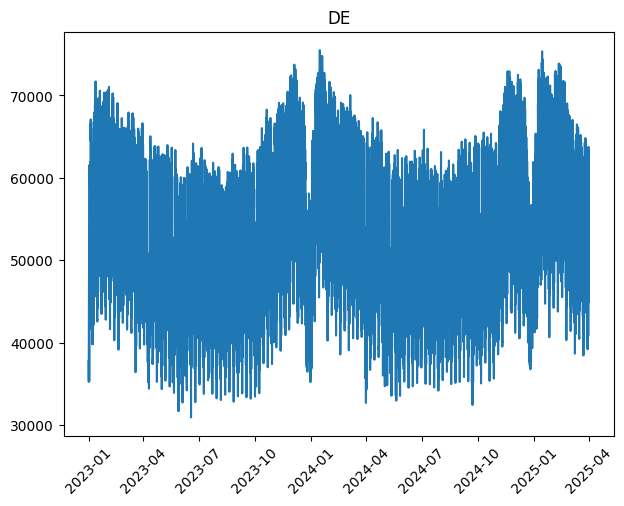

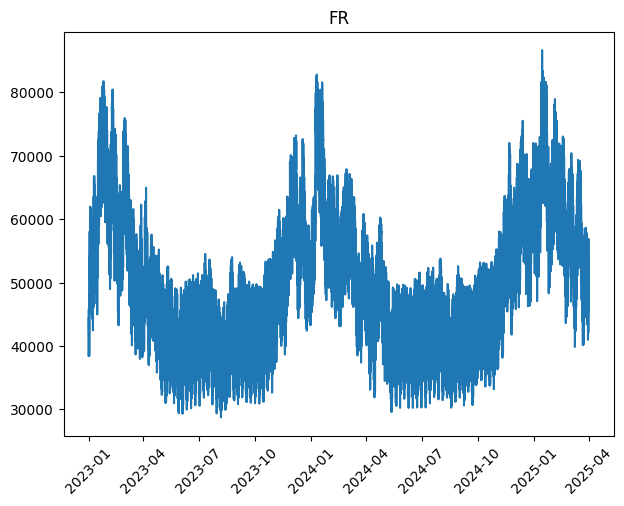

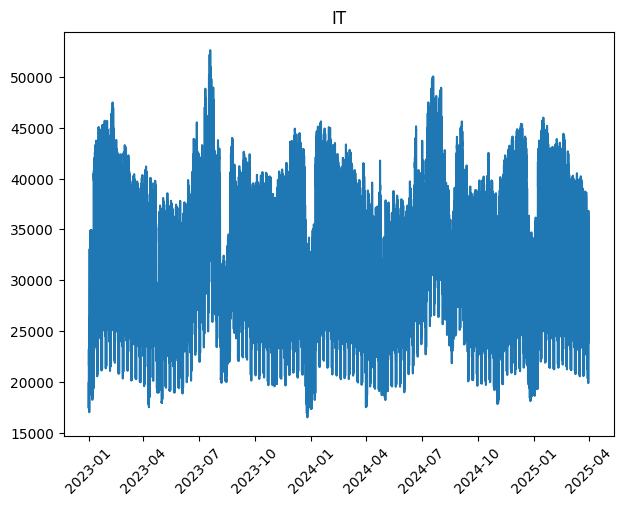

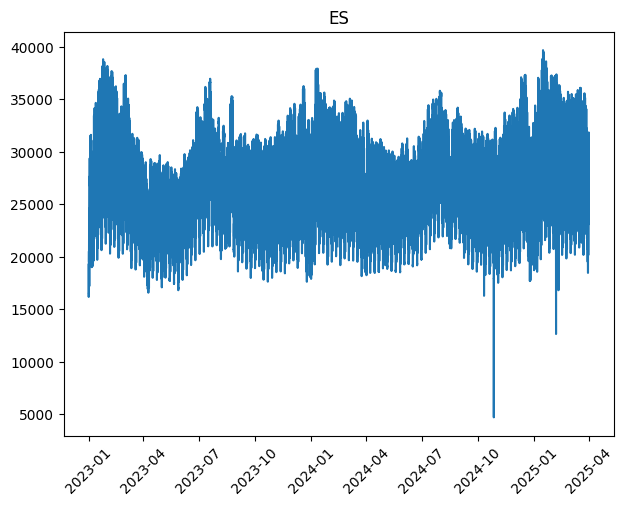

In [52]:
for c in ['DE','FR','IT','ES']:
    plt.plot(data[data['CountryCode']==c]['Date'],data[data['CountryCode']==c]['Value'])
    plt.title(c)
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

# Seasonal Components Analysis

- DE – Germany
    - Trend: Smooth upward trend with a dip around early 2024.
    - Weekly: Clear weekday/weekend contrast.
    - Yearly: Peaks around January and November, valleys in summer.
    - Daily: Strong bimodal pattern (morning and evening peaks).

- FR – France
    - Trend: Volatile start, then more stable.
    - Weekly: Weekday usage clearly higher.
    - Yearly: Strong seasonal variation with winter peaks.
    - Daily: Single peak in mid-day, but not as strong as Germany.

- IT – Italy
    - Trend: Less smooth, possibly due to noise 
    - Weekly: Similar weekday/weekend pattern.
    - Yearly: Multiple seasonal fluctuations — may need more regularization.
    - Daily: Similar to DE.

- ES – Spain
    - Trend: Noisy but slight upward trend.
    - Weekly: Lower demand on weekends.
    - Yearly: Multiple peaks — shows complex seasonality.
    - Daily: Clear peak in late afternoon/evening.

14:47:00 - cmdstanpy - INFO - Chain [1] start processing
14:47:02 - cmdstanpy - INFO - Chain [1] done processing


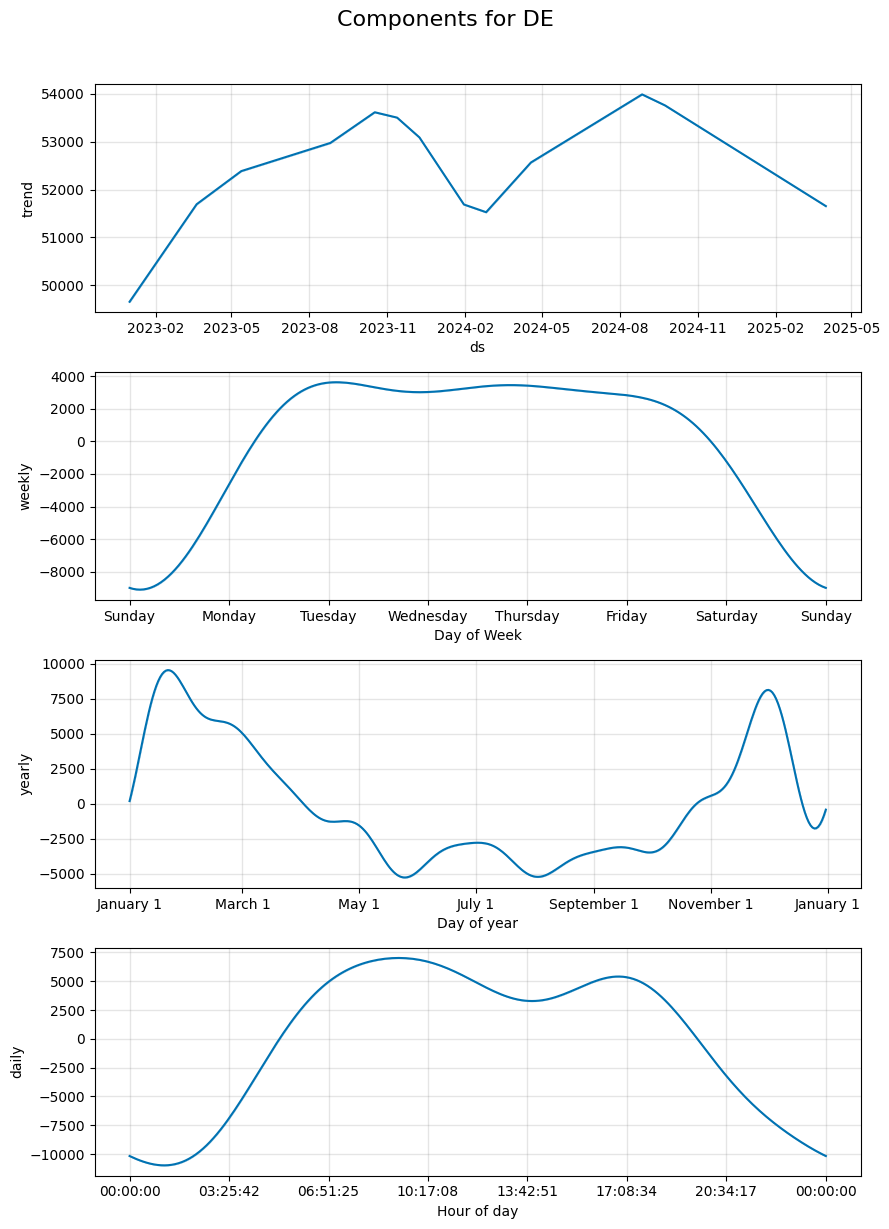

14:47:04 - cmdstanpy - INFO - Chain [1] start processing
14:47:11 - cmdstanpy - INFO - Chain [1] done processing


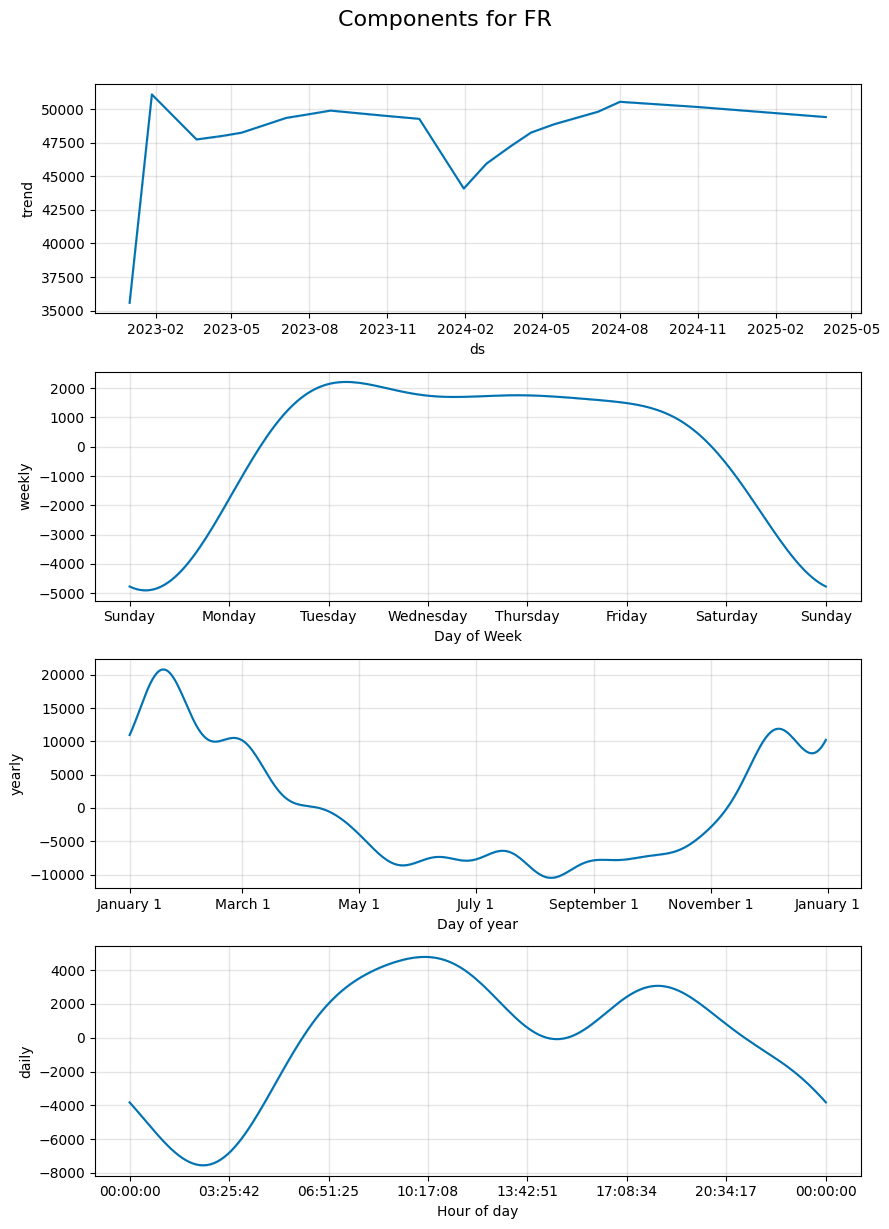

14:47:14 - cmdstanpy - INFO - Chain [1] start processing
14:47:18 - cmdstanpy - INFO - Chain [1] done processing


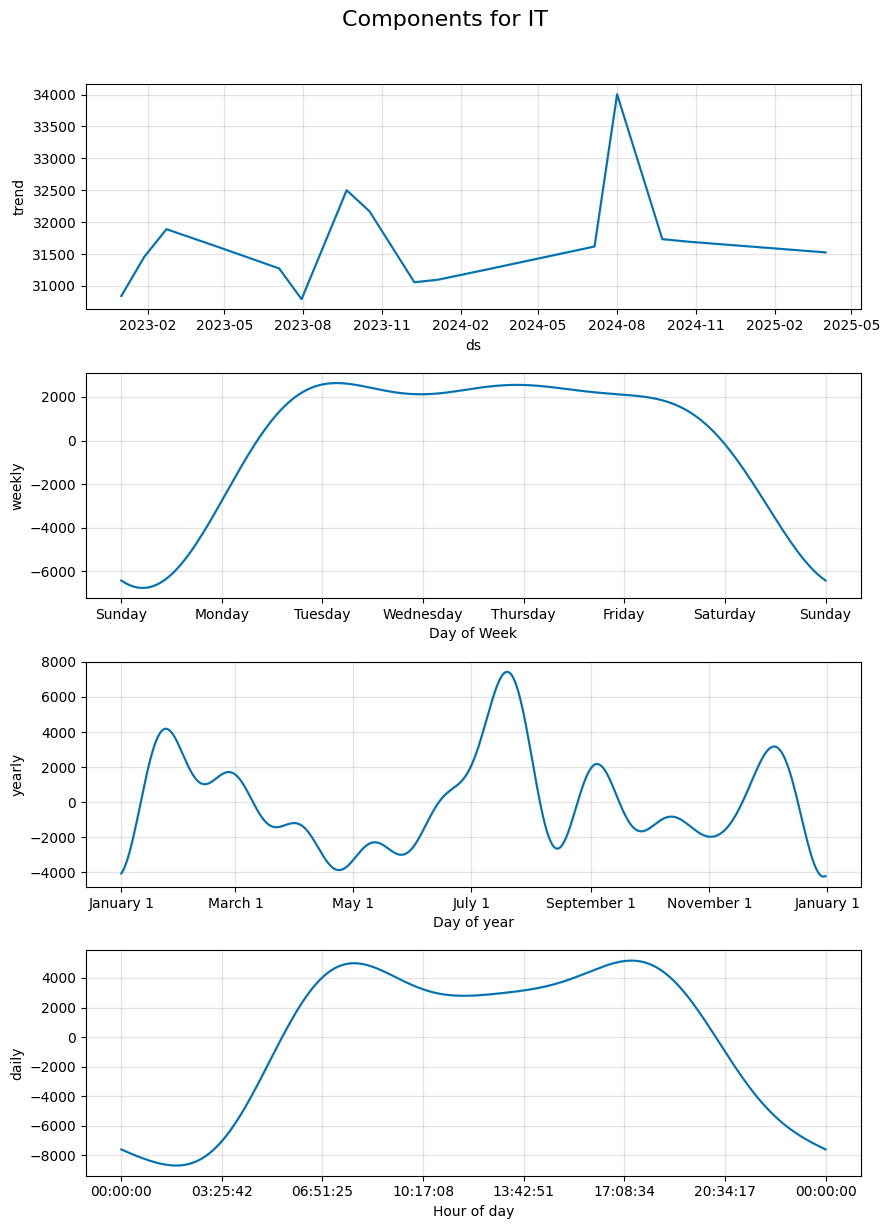

14:47:20 - cmdstanpy - INFO - Chain [1] start processing
14:47:26 - cmdstanpy - INFO - Chain [1] done processing


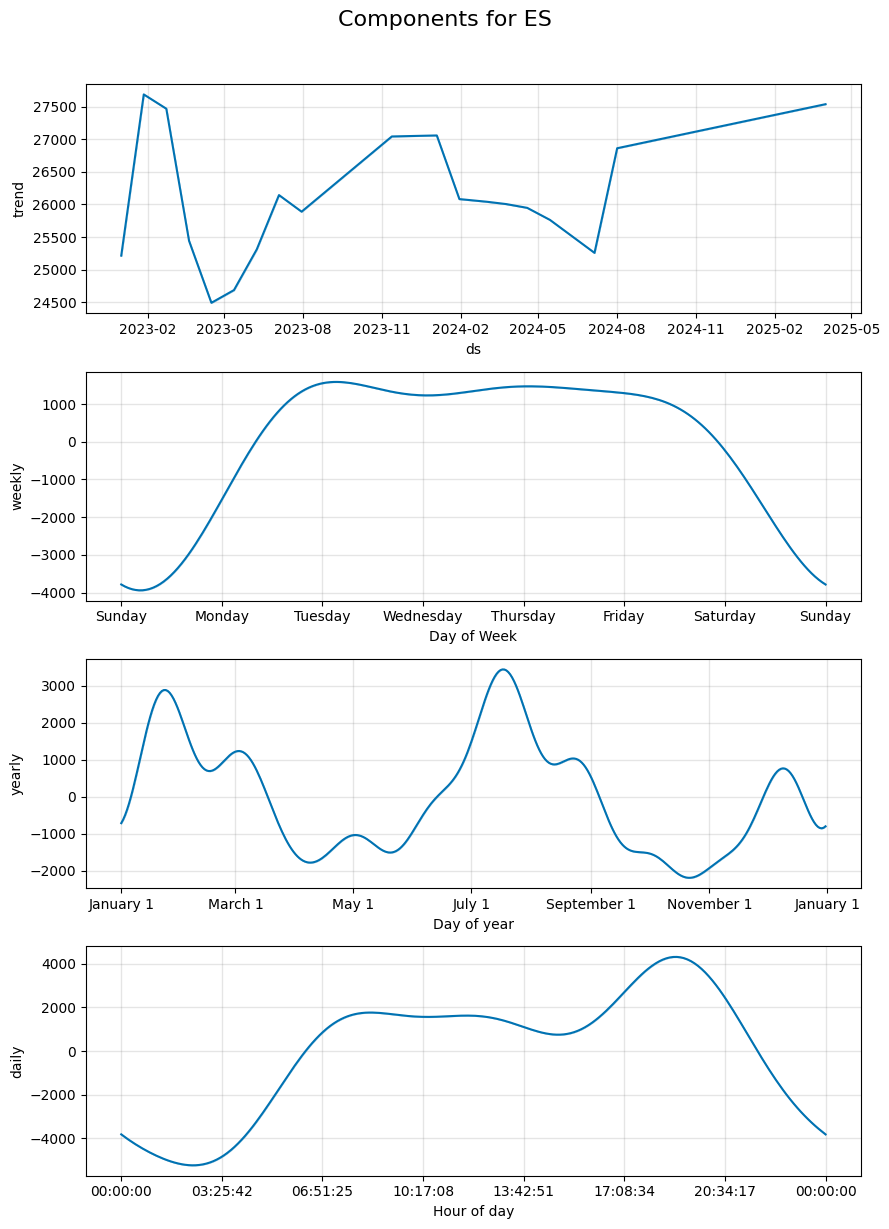

In [51]:
for c in ['DE','FR','IT','ES']:    
    df_prophet=data[data['CountryCode']==c][['Date','Value']].rename(columns={'Date': 'ds', 'Value': 'y'})
    mod=Prophet(daily_seasonality=True,weekly_seasonality=True,yearly_seasonality=True).fit(df_prophet)
    forecast=mod.predict(df_prophet)
    mod.plot_components(forecast).suptitle(f'Components for {c}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Feature Relationships

- Temp_C (Temperature):
Has the strongest positive correlation (~0.09), meaning as temperature rises, electricity load tends to rise slightly — possibly due to cooling demand (AC usage).

- Humidity:
Slight negative correlation, suggesting higher humidity might be associated with slightly lower electricity usage, though it's weak.

- WindSpeed, SolarRadiation:
Weak positive correlations; may relate to renewable generation but not directly predictive of load here.

- CloudCover:
Near-zero correlation — no meaningful linear relationship with load in this dataset

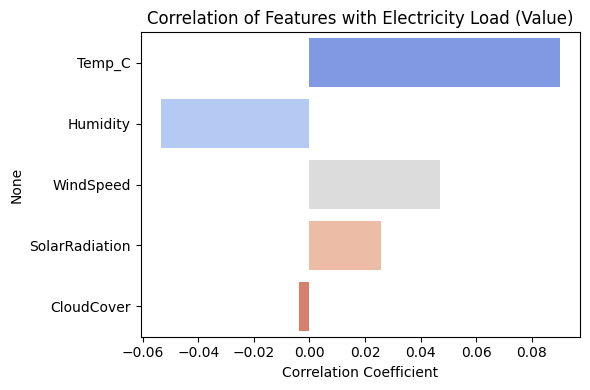

In [60]:
features = ['Temp_C', 'Humidity', 'WindSpeed', 'SolarRadiation', 'CloudCover']
# Calculate correlation of each feature with 'Value'
correlations = data[features + ['Value']].corr()['Value'].drop('Value')

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=correlations.values, y=correlations.index, hue=correlations.index, palette='coolwarm', legend=False)
plt.title('Correlation of Features with Electricity Load (Value)')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()